In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("All libraries loaded successfully ✅")

Device: cuda
All libraries loaded successfully ✅


In [8]:
df = pd.read_csv("SUNPHARMA.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,SUNPHARMA,EQ,1699.10,1800.0,1835.05,1760.0,1835.05,1835.05,1825.90,3024,5.521525e+11,NaN,NaN,NaN
1,2000-01-04,SUNPHARMA,EQ,1835.05,1960.0,1960.00,1763.0,1811.50,1810.45,1805.97,5787,1.045115e+12,NaN,NaN,NaN
2,2000-01-05,SUNPHARMA,EQ,1810.45,1845.0,1845.00,1740.0,1745.00,1746.90,1766.69,6105,1.078564e+12,NaN,NaN,NaN
3,2000-01-06,SUNPHARMA,EQ,1746.90,1750.0,1795.00,1735.0,1748.00,1745.20,1749.32,3472,6.073632e+11,NaN,NaN,NaN
4,2000-01-07,SUNPHARMA,EQ,1745.20,1705.0,1705.00,1605.6,1605.60,1605.60,1621.51,4125,6.688740e+11,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   str    
 1   Symbol              5306 non-null   str    
 2   Series              5306 non-null   str    
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover            5306 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4778 non-null   float64
 14  %Deliverble         4778 non-null   float64
dtypes: float64(11), int64(1), str(3)
memory usage: 621.9 KB


In [10]:
df.isnull().sum()

Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     528
%Deliverble            528
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# Remove unnecessary columns (not part of 11 required features)
df = df.drop(['Symbol', 'Series'], axis=1)
df.head()

,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,1699.10,1800.0,1835.05,1760.0,1835.05,1835.05,1825.90,3024,5.521525e+11,NaN,NaN,NaN
1,2000-01-04,1835.05,1960.0,1960.00,1763.0,1811.50,1810.45,1805.97,5787,1.045115e+12,NaN,NaN,NaN
2,2000-01-05,1810.45,1845.0,1845.00,1740.0,1745.00,1746.90,1766.69,6105,1.078564e+12,NaN,NaN,NaN
3,2000-01-06,1746.90,1750.0,1795.00,1735.0,1748.00,1745.20,1749.32,3472,6.073632e+11,NaN,NaN,NaN
4,2000-01-07,1745.20,1705.0,1705.00,1605.6,1605.60,1605.60,1621.51,4125,6.688740e+11,NaN,NaN,NaN


In [13]:
# Convert Date column to datetime and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                5306 non-null   datetime64[us]
 1   Prev Close          5306 non-null   float64       
 2   Open                5306 non-null   float64       
 3   High                5306 non-null   float64       
 4   Low                 5306 non-null   float64       
 5   Last                5306 non-null   float64       
 6   Close               5306 non-null   float64       
 7   VWAP                5306 non-null   float64       
 8   Volume              5306 non-null   int64         
 9   Turnover            5306 non-null   float64       
 10  Trades              2456 non-null   float64       
 11  Deliverable Volume  4778 non-null   float64       
 12  %Deliverble         4778 non-null   float64       
dtypes: datetime64[us](1), float64(11), int64(1)
memory usage: 5

In [14]:
# Forward fill then backward fill for NaN values
df = df.ffill()
df = df.bfill()

# Final check
df.isnull().sum()

Date                  0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
%Deliverble           0
dtype: int64

In [15]:
df.shape

(5306, 13)

In [16]:
# 11 required features as per assignment
feature_cols = ['Prev Close', 'Open', 'High', 'Low', 'Last',
                'Close', 'VWAP', 'Volume', 'Turnover',
                'Trades', 'Deliverable Volume']

# Keep Date separately for plotting later
dates = df['Date'].values
data  = df[feature_cols].values

print("Features:", feature_cols)
print("Data shape:", data.shape)

Features: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']
Data shape: (5306, 11)


In [17]:
# Train/Test split BEFORE scaling to prevent data leakage
split = int(0.8 * len(data))

train_data  = data[:split]
test_data   = data[split:]
train_dates = dates[:split]
test_dates  = dates[split:]

print("Train size:", len(train_data))
print("Test  size:", len(test_data))

Train size: 4244
Test  size: 1062


In [18]:
# Fit scaler ONLY on train data to prevent data leakage
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print("train_scaled min/max:", train_scaled.min(), train_scaled.max())
print("test_scaled  min/max:", test_scaled.min(),  test_scaled.max())

train_scaled min/max: 0.0 1.0
test_scaled  min/max: 0.0005213575210748991 1.4847001393973795


In [19]:
# Sliding window with overlap=5
# Input  : last 10 days (all 11 features)
# Output : next 5 days  (all 11 features)

def create_sequences(data, input_days=10, output_days=5, overlap=5):
    X, y = [], []
    step = input_days - overlap   # step = 5
    i = 0
    while i + input_days + output_days <= len(data):
        X.append(data[i : i + input_days])
        y.append(data[i + input_days : i + input_days + output_days])
        i += step
    return np.array(X), np.array(y)

In [20]:
X_train, y_train = create_sequences(train_scaled)
X_test,  y_test  = create_sequences(test_scaled)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape)
print("y_test  shape:", y_test.shape)

X_train shape: (846, 10, 11)
y_train shape: (846, 5, 11)
X_test  shape: (210, 10, 11)
y_test  shape: (210, 5, 11)


In [21]:
print("First X sample:\n", X_train[0])
print("\nFirst y sample:\n", y_train[0])

First X sample:
 [[5.48628142e-01 5.66260613e-01 5.50865113e-01 6.29025512e-01
  6.01052732e-01 6.00724249e-01 5.89524979e-01 1.03835350e-05
  2.16530186e-05 2.30170593e-02 2.33850639e-06]
 [6.00724249e-01 6.25322997e-01 5.94985876e-01 6.30280217e-01
  5.92037516e-01 5.91297517e-01 5.81972990e-01 2.07821240e-05
  4.15163697e-05 2.30170593e-02 2.33850639e-06]
 [5.91297517e-01 5.82871908e-01 5.54378531e-01 6.20660811e-01
  5.66580534e-01 5.66945126e-01 5.67088790e-01 2.19789214e-05
  4.28641369e-05 2.30170593e-02 2.33850639e-06]
 [5.66945126e-01 5.47803618e-01 5.36723164e-01 6.18569636e-01
  5.67728969e-01 5.66293685e-01 5.60506851e-01 1.20695892e-05
  2.38776699e-05 2.30170593e-02 2.33850639e-06]
 [5.66293685e-01 5.31192322e-01 5.04943503e-01 5.64450021e-01
  5.13216576e-01 5.12798896e-01 5.12076361e-01 1.45271638e-05
  2.63561725e-05 2.30170593e-02 2.33850639e-06]
 [5.12798896e-01 5.10889627e-01 5.02118644e-01 5.11083229e-01
  4.90018184e-01 4.84537860e-01 4.97021644e-01 1.54793328e-05

In [22]:
# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

print(X_train_t.shape)
print(y_train_t.shape)

torch.Size([846, 10, 11])
torch.Size([846, 5, 11])


In [23]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=11, hidden_size=128, num_layers=2, output_days=5, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.output_days = output_days

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)

        self.fc = nn.Linear(hidden_size, input_size * output_days)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]          # last time step
        out = self.fc(out)
        out = out.view(-1, self.output_days, 11)
        return out

In [24]:
model = LSTMModel().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTotal trainable parameters:", total_params)

LSTMModel(
  (lstm): LSTM(11, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=55, bias=True)
)

Total trainable parameters: 211383


In [25]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [26]:
epochs = 50
train_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [1/50], Loss: 0.041545
Epoch [5/50], Loss: 0.030023
Epoch [10/50], Loss: 0.013574
Epoch [15/50], Loss: 0.008214
Epoch [20/50], Loss: 0.006429
Epoch [25/50], Loss: 0.003692
Epoch [30/50], Loss: 0.002860
Epoch [35/50], Loss: 0.002659
Epoch [40/50], Loss: 0.002065
Epoch [45/50], Loss: 0.001822
Epoch [50/50], Loss: 0.001734


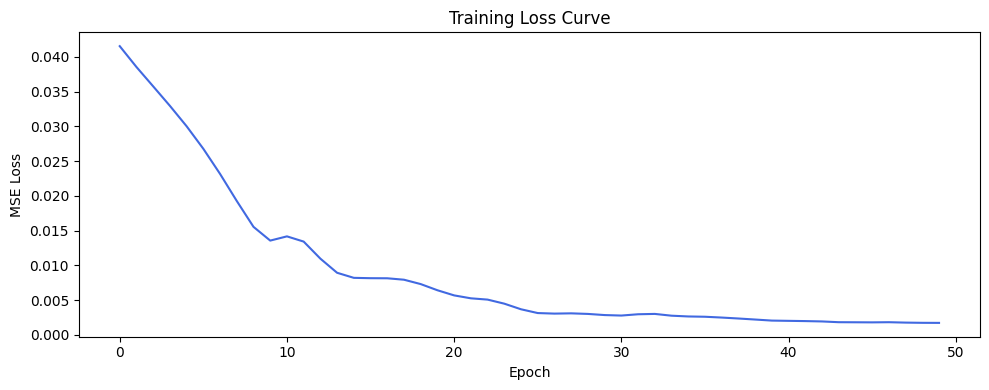

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='royalblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Curve')
plt.tight_layout()
plt.show()

In [28]:
model.eval()

with torch.no_grad():
    y_pred_t = model(X_test_t)

y_pred_t.shape

torch.Size([210, 5, 11])

In [29]:
y_test_np = y_test_t.cpu().numpy()
y_pred_np = y_pred_t.cpu().numpy()

In [30]:
# Flatten for inverse transform: (n_samples * output_days, 11)
y_test_flat = y_test_np.reshape(-1, 11)
y_pred_flat = y_pred_np.reshape(-1, 11)

# Inverse scale to original price range
y_test_inv = scaler.inverse_transform(y_test_flat)
y_pred_inv = scaler.inverse_transform(y_pred_flat)

print("y_test_inv shape:", y_test_inv.shape)
print("y_pred_inv shape:", y_pred_inv.shape)

y_test_inv shape: (1050, 11)
y_pred_inv shape: (1050, 11)


In [31]:
mse  = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_inv, y_pred_inv)

print("MSE :", round(mse,  4))
print("RMSE:", round(rmse, 4))
print("MAE :", round(mae,  4))

MSE : 2.071936641530788e+28
RMSE: 143942232910664.12
MAE : 30285009780736.0


In [32]:
# Per-feature RMSE
print("Per-feature RMSE:")
for i, col in enumerate(feature_cols):
    col_rmse = np.sqrt(mean_squared_error(y_test_inv[:, i], y_pred_inv[:, i]))
    print(f"  {col:<25}: {col_rmse:.4f}")

Per-feature RMSE:
  Prev Close               : 68.7314
  Open                     : 90.7820
  High                     : 88.3766
  Low                      : 73.8833
  Last                     : 69.4664
  Close                    : 82.9245
  VWAP                     : 72.4861
  Volume                   : 9432492.1670
  Turnover                 : 477402390415363.1875
  Trades                   : 107530.7614
  Deliverable Volume       : 2937487.4582


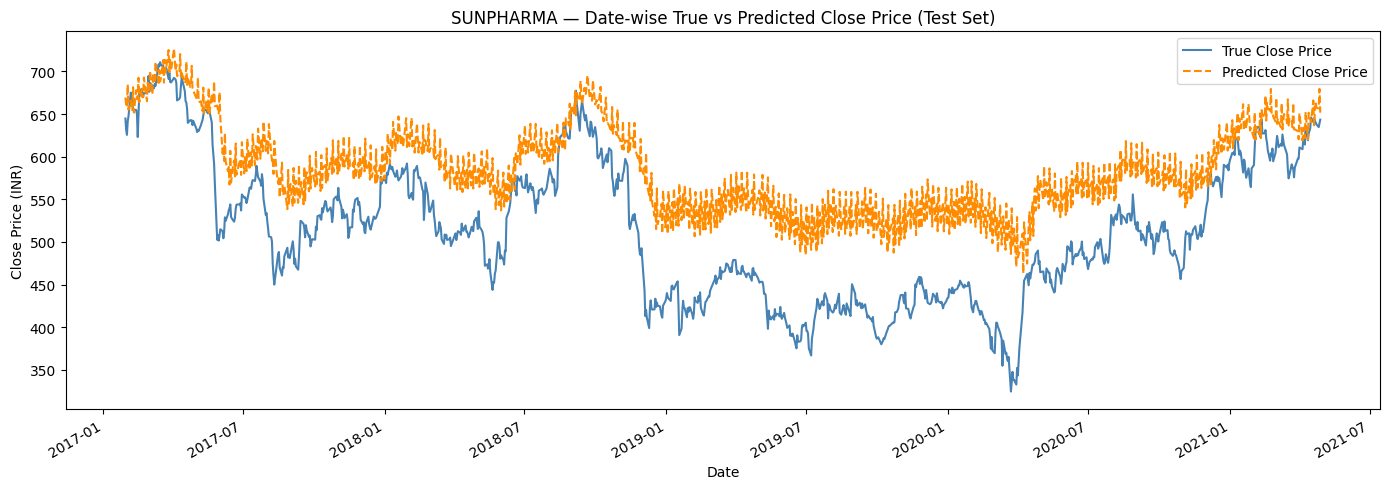

In [33]:
# Date-wise True vs Predicted Close Price plot
CLOSE_IDX   = feature_cols.index('Close')   # index 5
INPUT_DAYS  = 10
OUTPUT_DAYS = 5
STEP        = 5   # INPUT_DAYS - overlap

pred_dates = []
pred_close = []
true_close = []

n_samples = y_test_np.shape[0]

for i in range(n_samples):
    start_idx = i * STEP + INPUT_DAYS
    for j in range(OUTPUT_DAYS):
        date_idx = start_idx + j
        if date_idx < len(test_dates):
            pred_dates.append(pd.to_datetime(test_dates[date_idx]))
            pred_close.append(y_pred_inv[i * OUTPUT_DAYS + j, CLOSE_IDX])
            true_close.append(y_test_inv[i * OUTPUT_DAYS + j,  CLOSE_IDX])

plt.figure(figsize=(14, 5))
plt.plot(pred_dates, true_close,  label='True Close Price',      color='steelblue',  linewidth=1.5)
plt.plot(pred_dates, pred_close,  label='Predicted Close Price', color='darkorange', linewidth=1.5, linestyle='--')
plt.xlabel('Date')
plt.ylabel('Close Price (INR)')
plt.title('SUNPHARMA — Date-wise True vs Predicted Close Price (Test Set)')
plt.legend()
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [34]:
torch.save(model.state_dict(), 'sunpharma_lstm_model.pth')
print("Model saved as sunpharma_lstm_model.pth")

Model saved as sunpharma_lstm_model.pth
